# ERP analysis using MNE



## Top-down view onto this notebook
To do: write here

## Exercise 2: Import, preprocess and inspect the data

Experimental setup: See notes on dataset

General EEG data information: See solutions file

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score # added cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import sklearn.metrics as metrics
import scipy as sp
import scipy.stats as stats
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

np.random.seed(42)

In [2]:
# Preparations

def load_and_preprocess_raw(header_file, filter_band=(0.5, 16)):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True)
    raw.set_montage("standard_1020")
    raw.filter(*filter_band, method="iir")
    raw.pick_types(eeg=True)
    return raw

def epoch_raw(raw, decimate=10):
    target_ids = list(range(111, 117))     # [111, 112, 113, 114, 115, 116]
    non_target_ids = list(range(101, 107)) # [101, 102, 103, 104, 105, 106]

    event_id = {f"Word_{i-110}/Target": i for i in target_ids}
    # {'Word_1/Target': 111, 'Word_2/Target': 112, 'Word_3/Target': 113, 'Word_4/Target': 114, 'Word_5/Target': 115, 'Word_6/Target': 116}
    
    event_id.update({f"Word_{i-100}/NonTarget": i for i in non_target_ids})
    # Same idea for non targets
    
    evs = mne.events_from_annotations(raw)[0]

    # print(evs.shape) # (548,3)
    # print(evs)
    # [[     0      0  99999]
    #  [  7538      0    201]
    #  [ 12077      0    101]
    #  ...
    #  [216368      0    101]
    #  [216621      0    103]
    #  [219940      0    255]]
    
    #epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
    #                   proj=False, tmax=1)

    epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
                       proj=False, tmax=1, baseline=None)
    return epoch

# Get the data path
data_dir = Path.cwd() / "data_a7" 
header_files = data_dir.glob("auditoryAphasia*.vhdr")

# Load the data, preprocess and slice it into epochs
epochs = list()

counter = 0 # to be removed
raw_data_storage = list() # added for insight - (to be removed later)

for f in header_files:
    raw_data = load_and_preprocess_raw(f)
    raw_data_storage.append(raw_data) # added for insight - (to be removed later)
    counter+=1 # to be removed
    epochs.append(epoch_raw(raw_data))

# Overwrite epochs list to save memory
epochs = mne.concatenate_epochs(epochs) # len(epochs) = 3240

# Combine 6 epochs into a single iteration (6 stimuli together form a single iteration)
iterations = [epochs[i:i+6] for i in np.arange(0, epochs.events.shape[0],6)] # for loop goes from 0 to 3234 in steps of 6

# Assert that each iteration contains exactly 1 Target
assert all([len(iteration["Target"]) == 1 for iteration in iterations]), "Number of targets in single iterations is unequal to 1."

# 15 iterations form a single trial
trials = [iterations[i:i+15] for i in np.arange(0,len(iterations),15)]

In [3]:
# Printing the objects for visualisation
print(counter)
print(len(raw_data_storage))
print("raw_data 4= ", raw_data_storage[1].info)
print("raw_data 5= ", raw_data_storage[2].info)


print("raw_data = ",raw_data)
print("\nepochs = \n",epochs)
print("\nlen(epochs) = ", len(epochs))

#print("\n iterations[0] = \n",iterations[0])
print("len(iterations) = ", len(iterations), " (each consists of 6 epochs)")
print("len(trials) = ", len(trials), " (each consists of 15 iterations)")

print("\nWe have 36 trials, each consists of 15 iterations (making 36 * 15 = 540 iterations in total)")
print("Each iteration consists of 6 events/words (making 540 * 6 = 3240 stimuli in total)")
print("This is in line with the total amount of epochs: 3240")

6
6
raw_data 4=  <Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.5 Hz
 lowpass: 16.0 Hz
 meas_date: 2015-07-28 11:52:15 UTC
 nchan: 63
 projs: []
 sfreq: 1000.0 Hz
>
raw_data 5=  <Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.5 Hz
 lowpass: 16.0 Hz
 meas_date: 2015-07-28 12:10:04 UTC
 nchan: 63
 projs: []
 sfreq: 1000.0 Hz
>
raw_data =  <RawBrainVision | auditoryAphasia_6D_Block1_Run7.eeg, 63 x 220240 (220.2 s), ~105.9 MiB, data loaded>

epochs = 
 <EpochsArray | 3240 events (all good), -0.2 – 1 s (baseline off), ~188.5 MiB, data loaded,
 'Word_1/Target': 90
 'Word_2/Target': 90
 'Word_3/Target': 90
 'Word_4/Target': 90
 'Word_5/Target': 90
 'Word_6/Target': 90
 'Word_1/NonTarget'

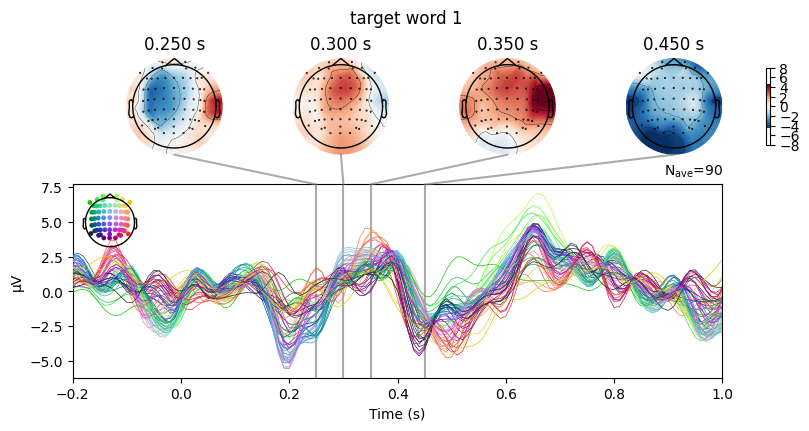

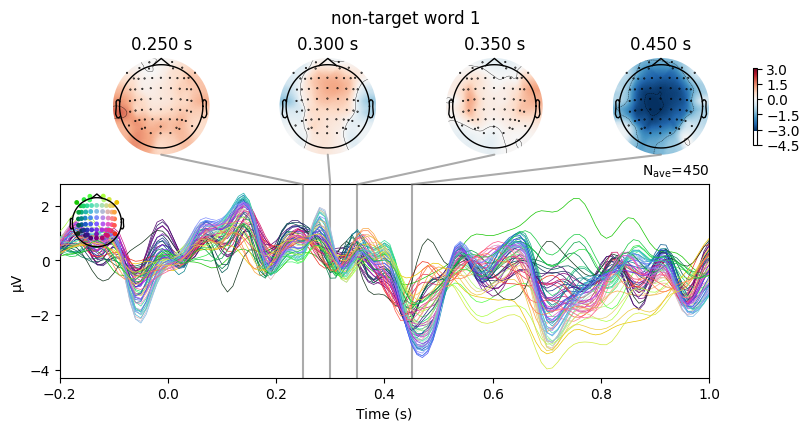

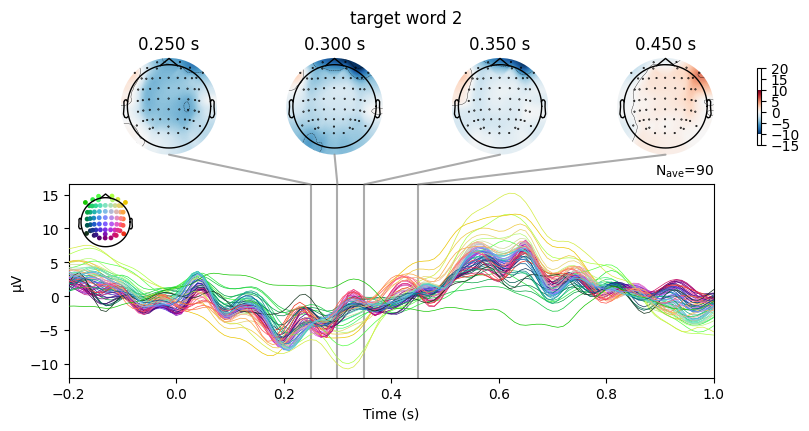

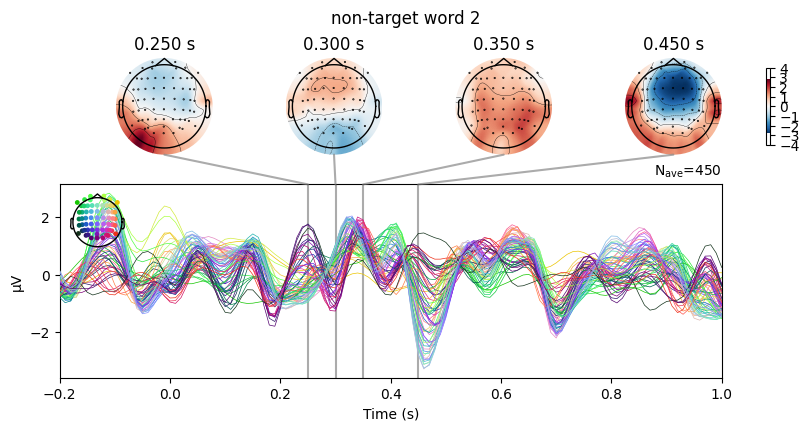

In [4]:
# Solution

# 2:
# Frequency range has been limited to [0,250]Hz. 
# Sampling rate is 1000 Hz.
# The intended temporal difference between 2 stimulus onsets is 250 ms. 
# This means that epochs will overlap a bit. This is not constant up to the ms because of delays in hardware and software, 
# drivers, audio cards, speakers, windows, etc.

# 3:
# -load_and_preprocess_raw() takes the header file and the desired frequency filter range. It separates the EEG from the non-EEG
#   channels, defines the channel layout (montage), applies the band-pass filter and returns the filtered EEG channels.
# -epoch_raw() takes the filtered EEG channels from load_and_preprocess_raw() and slices them up into epochs. The event IDs of 
#   these epochs will be replaced by their conditions: 'Word_i/Target' or 'Word_i/NonTarget' where i ∈ [1,6]. 
# -Event dictionaries like `event_id` are used when extracting epochs from continuous data. The `/` character in the dictionary 
#   keys allows pooling across conditions by requesting partial condition descriptors (i.e., requesting `Word_i` will select all 
#   epochs with that stimulus; requesting `Target` will select all epochs with targets.

# -Decimation of the sampling rate: we have a sampling rate of 1000Hz, as can be seen from the info of our epochs. This is a 
#   lot of data for our purposes.
# -We decimate with a factor 10, meaning every 10 samples, we only actually save 1 in our data. Thus our recorded sampling rate
#   of 1000 Hz becomes a realised sampling rate of 100Hz. Since we filter between 0.5 and 16Hz this is not an issue because 16Hz
#   is still below the Nyquist frequency

# 4:

scalp_times = (0.25, 0.30, 0.35, 0.45)
for i in np.arange(1,6):
    if i < 3:     # to not have a massive notebook
        epochs[f'Word_{i}']["Target"].average().plot_joint(title=f'target word {i}', times=scalp_times)
        epochs[f'Word_{i}']["NonTarget"].average().plot_joint(title=f'non-target word {i}', times=scalp_times)

plt.show()

# It becomes evident that target words have a larger negative response around 200ms, specifically around the sides and 
# the back of the head. 
# Also, the spread of the channels increases at 250ms for the target words. 

## Exercise 3: Calibration


### Comparing LDA vs sLDA vs BT-LDA on calibration data
Here the AUC scores of the three classifiers LDA, SLDA and BTLDA are compared. A selection of all trials is used for calibration data. This calibration data is split into a train set to fit the classifier and a test set for evaluation (i.e., AUC scores).
The AUC score is computed in two different ways: `compare_auc_single_trial_interval` and `compute_auc_with_cv`.

Here below follows an explanation of the methods:

`get_jumping_means` extracts features by averaging over the selected time intervals. 

`compare_auc_single_trial_interval` uses a single `train_test_split` which you can experiment with by tuning the following parameters:
- you can determine which part of all trials is going to be used as calibration data
- you can pass different values for `test_size` of the train:test ratio when splitting the calibration data
- you can determine the time intervals to average the raw data over

`compute_auc_with_cv` computes the AUC scores by using a K-fold cross-validation instead of à single `train_test_split`. Here you can also experiment by changing the following parameters:
- you can determine which part of all trials is going to be used as calibration data (default is trials [0-12])
- you can determine the time intervals to average the raw data over
- you can determine the nr of folds

#### Functions

In [5]:
print((trials[0][0]).info)
print((trials[0][0]).info["nchan"])

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.5 Hz
 lowpass: 16.0 Hz
 meas_date: 2015-07-28 11:04:07 UTC
 nchan: 63
 projs: []
 sfreq: 100.0 Hz
>
63


In [6]:
# comparing LDA - BT-LDA - sLDA
# data is in channel prime order
# evaulation method added from Jan's example_toeplitz_lda_simple.py

from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# See cell block in dump file for documentation on how this function works
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X

def compare_auc_single_trial_interval(trials, start=0, stop=12, test_size=0.2, only_auc = True, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), plot_roc_curves = True):
    """
    compares LDA vs sLDA vs BT-LDA on calibration data
    
    calibration data is determined by a selection of trials [start - stop], e.g. [0-12]
    note that this is not robust! the interval matters. You can check this by passing different values for [start - stop]
    The full dataset here is the selected interval of calibration data. This interval will be split with sklearn's train_test_split method.

    input:
    - start: first trial to take as calibration data
    - stop: last trial to take as calibration data
    - test_size: the test part in the ratio train:test when splitting the calibration data. 
    - only_auc: if True, only the auc scores are printed for all three classifiers. If False, then the balanced auc scores are printed too.
    - ival_bounds: time interval boundaries to average the raw calibration trials over
    - plot_roc_curves: if True, also plot the ROC curves. if False, then only the AUC scores are printed. 
    """

    raw_calibration_trials = trials[start:stop] # change start & stop trial
    # online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds
    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    #X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
    # Exp_6
    X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=test_size, shuffle=False)

    # Evaluation of Jan's simple toeplitz example script

    print("AUC scores computed using a single train_test_split using trials [{}:{}] with test_size = {}".format(start,stop,test_size))

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    clf_lda.fit(X_train,y_train)

    y_df = clf_lda.decision_function(X_test)
    roc_auc_lda = roc_auc_score(y_test, y_df)
    y_pred = clf_lda.predict(X_test)
    bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC LDA: ", roc_auc_lda)
    else:
        print("LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_lda)
        print("bal_acc_auc: ",bal_acc_auc_lda)

    ### sLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    clf_slda.fit(X_train,y_train)

    y_df = clf_slda.decision_function(X_test)
    roc_auc_slda = roc_auc_score(y_test, y_df)
    y_pred = clf_slda.predict(X_test)
    bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC SLDA: ", roc_auc_slda)
    else:     
        print("\nsLDA scores with channel prime data")
        print("roc_auc: ",roc_auc_slda)
        print("bal_acc_auc: ",bal_acc_auc_slda)

    ### BT-LDA
    from toeplitzlda.classification import (
        EpochsVectorizer,
        ShrinkageLinearDiscriminantAnalysis,
        ToeplitzLDA,
    )

    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    clf_btlda.fit(X_train,y_train)

    y_df = clf_btlda.decision_function(X_test)
    roc_auc_btlda = roc_auc_score(y_test, y_df)
    y_pred = clf_btlda.predict(X_test)
    bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC BT-LDA: ", roc_auc_btlda)
    else:    
        print("\nBT-LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_btlda)
        print("bal_acc_auc: ",bal_acc_auc_btlda)


    # ------------------------------------------------------------------------------------------------------------
    #
    # comparing LDA - BT-LDA - sLDA using other evaluation method
    # Evaluation of ex. 3
    if plot_roc_curves:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

        ### LDA

        lda = LDA()
        ldaclf = lda.fit(X_train, y_train)
        fpr_lda, tpr_lda, thresholds_lda = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

        metrics.RocCurveDisplay(fpr=fpr_lda, tpr=tpr_lda).plot(ax=axes[0])
        axes[0].plot([0, 1],[0,1], '--') 
        axes[0].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
        axes[0].set_title("AUC-ROC of LDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))

        ### Shrinkage LDA

        slda = LDA(solver='lsqr',shrinkage = 'auto')
        slda.fit(X_train, y_train)

        fpr_slda, tpr_slda, thresholds_slda = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_slda, tpr=tpr_slda).plot(ax=axes[1])
        axes[1].plot([0, 1],[0,1], '--')
        axes[1].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
        axes[1].set_title("AUC-ROC of sLDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))
        ### BT-LDA

        # TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
        nch = (trials[0][0]).info["nchan"]
        btlda = ToeplitzLDA(n_channels= nch) 
        btlda.fit(X_train, y_train) 

        fpr_btlda, tpr_btlda, thresholds_btlda = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_btlda, tpr=tpr_btlda).plot(ax=axes[2])
        axes[2].plot([0, 1],[0,1], '--')
        axes[2].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
        axes[2].set_title("AUC-ROC of BT-LDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))
        
        plt.show()


#### Using different test_size values

In [7]:
# train_test_split using test_size = 0.2 and test_size = 0.3
# using the time intervals [0.1, 0.2, 0.3, 0.4, 0.5] (Default)
compare_auc_single_trial_interval(trials,0,12,test_size=0.1,plot_roc_curves=False)
compare_auc_single_trial_interval(trials,0,12,test_size=0.2,plot_roc_curves=False)
compare_auc_single_trial_interval(trials,0,12,test_size=0.3,plot_roc_curves=False)

AUC scores computed using a single train_test_split using trials [0:12] with test_size = 0.1
AUC LDA:  0.8197530864197531
AUC SLDA:  0.8117283950617283
AUC BT-LDA:  0.8253086419753086
AUC scores computed using a single train_test_split using trials [0:12] with test_size = 0.2
AUC LDA:  0.817746913580247
AUC SLDA:  0.8265432098765431
AUC BT-LDA:  0.8294753086419753
AUC scores computed using a single train_test_split using trials [0:12] with test_size = 0.3
AUC LDA:  0.7780521262002743
AUC SLDA:  0.8282578875171468
AUC BT-LDA:  0.8244170096021949


#### Using different time interval boundaries

In [8]:
# train_test_split using test_size = 0.2 and test_size = 0.3
# Change: 9 time intervals of 50 ms
clf_ival_boundaries = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])
compare_auc_single_trial_interval(trials,0,12,test_size=0.2, ival_bounds = clf_ival_boundaries, plot_roc_curves=False)
compare_auc_single_trial_interval(trials,0,12,test_size=0.3, ival_bounds = clf_ival_boundaries, plot_roc_curves=False)

AUC scores computed using a single train_test_split using trials [0:12] with test_size = 0.2
AUC LDA:  0.703858024691358
AUC SLDA:  0.8141975308641975
AUC BT-LDA:  0.8399691358024691
AUC scores computed using a single train_test_split using trials [0:12] with test_size = 0.3
AUC LDA:  0.6967764060356653
AUC SLDA:  0.8390260631001372
AUC BT-LDA:  0.8471879286694102


#### Using different sample intervals
Note that the selected interval of trials matters. Selecting trials 0-12 yields different results than trials 2-14 or 4-16, even though they have the same dataset size. This variation in scores means that a single train_test_split is not a good evaluation method to measure the general performance. 

In [9]:
compare_auc_single_trial_interval(trials,0,12,test_size=0.2,plot_roc_curves=False) # trials [0-12]
compare_auc_single_trial_interval(trials,2,14,test_size=0.2,plot_roc_curves=False) # trials [2-14]
compare_auc_single_trial_interval(trials,4,16,test_size=0.2,plot_roc_curves=False) # trials [4-16]

AUC scores computed using a single train_test_split using trials [0:12] with test_size = 0.2
AUC LDA:  0.817746913580247
AUC SLDA:  0.8265432098765431
AUC BT-LDA:  0.8294753086419753
AUC scores computed using a single train_test_split using trials [2:14] with test_size = 0.2
AUC LDA:  0.8166666666666667
AUC SLDA:  0.8601851851851852
AUC BT-LDA:  0.8763888888888889
AUC scores computed using a single train_test_split using trials [4:16] with test_size = 0.2
AUC LDA:  0.7708333333333334
AUC SLDA:  0.7603395061728395
AUC BT-LDA:  0.7912037037037037


### Average AUC-score using cross-validation

#### Function

In [10]:
# Cross-validation instead of train_test_split
# LDA vs SLDA vs BT-LDA on calibration data

def compute_auc_with_cv(start=0, stop=12, trials=trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), cv_folds = 4, show_mean=True, show_folds=False):
    """
    Computes and prints the average AUC score of LDA, SLDA and BTLDA using cross-validation

    input:
    - trials
    - start
    - stop
    - ival_bounds
    - cv_folds
    - show_mean: If True, print the average AUC score across all folds. If False, do not print it.
    - show_folds: if True, print the AUC scores of all folds. If False, do not print the AUC score per fold
    """

    raw_calibration_trials = trials[start:stop] 
    #online_trials = trials[stop:] 
    clf_ival_boundaries = ival_bounds

    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    X = calibration_stimuli
    y = calibration_labels

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    auc_lda = cross_val_score(clf_lda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of LDA, all {} folds: {}".format(cv_folds, auc_lda))
    if show_mean:    
        print("Mean AUC score of LDA: \t\t", auc_lda.mean())

    ### SLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    auc_slda = cross_val_score(clf_slda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of sLDA, all {} folds: {}".format(cv_folds, auc_slda))
    if show_mean:     
        print("Mean AUC score of sLDA: \t", auc_slda.mean())

    ### BT-LDA
    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    auc_btlda = cross_val_score(clf_btlda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of BT-LDA, all {} folds: {}".format(cv_folds, auc_btlda))
    if show_mean:    
        print("Mean AUC score of BT-LDA: \t", auc_btlda.mean())



#### Compute AUC using cv with different sample intervals

In [11]:
# Comparing AUC scores from 4-fold cv
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("4-fold cross-validation:")

# Trial interval matters here too... look at the difference in AUC scores when selecting different samples of the data ([0-12], [2-14], ...)
print("\nUsing interval [0-12]") # This is the default
compute_auc_with_cv(start=0, stop=12, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [2-14]")
compute_auc_with_cv(start=2, stop=14, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [4-16]")
compute_auc_with_cv(start=4, stop=16, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [6-18]")
compute_auc_with_cv(start=6, stop=18, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)


4-fold cross-validation:

Using interval [0-12]
Mean AUC score of LDA: 		 0.7716296296296297
Mean AUC score of sLDA: 	 0.7519506172839506
Mean AUC score of BT-LDA: 	 0.754320987654321

Using interval [2-14]
Mean AUC score of LDA: 		 0.7591111111111111
Mean AUC score of sLDA: 	 0.7888641975308642
Mean AUC score of BT-LDA: 	 0.8002469135802469

Using interval [4-16]
Mean AUC score of LDA: 		 0.7821975308641975
Mean AUC score of sLDA: 	 0.796320987654321
Mean AUC score of BT-LDA: 	 0.8095061728395061

Using interval [6-18]
Mean AUC score of LDA: 		 0.8358271604938272
Mean AUC score of sLDA: 	 0.8452592592592593
Mean AUC score of BT-LDA: 	 0.861283950617284


#### Using smaller time intervals

In [12]:
# Time intervals of 100 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.1) # [0.1 0.2 0.3 0.4 0.5]
print("Using 4-fold cv - Time ivals of 100 ms:")
compute_auc_with_cv(trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)


# Time intervals of 50 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.05) # [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
print("\nUsing 4-fold cv - Time ivals of 50 ms:")
compute_auc_with_cv(trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)


# Time intervals of 20 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.02) # [0.1  0.12 ... 0.48 0.5 ]
print("\nUsing 4-fold cv - Time ivals of 20 ms:")
compute_auc_with_cv(trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)

# Time intervals of 10 ms but with a slightly different range
clf_ival_boundaries = np.arange(0.1,0.51,0.01) # gives an error of NaN values
clf_ival_boundaries = np.arange(0.05,0.51,0.01) # gives no error # [0.05 0.06 ... 0.49 0.5]
print("\nUsing 4-fold cv - Time ivals of 10 ms:")
compute_auc_with_cv(trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)

Using 4-fold cv - Time ivals of 100 ms:
Mean AUC score of LDA: 		 0.7716296296296297
Mean AUC score of sLDA: 	 0.7519506172839506
Mean AUC score of BT-LDA: 	 0.754320987654321

Using 4-fold cv - Time ivals of 50 ms:
Mean AUC score of LDA: 		 0.706641975308642
Mean AUC score of sLDA: 	 0.7656296296296295
Mean AUC score of BT-LDA: 	 0.7821234567901234

Using 4-fold cv - Time ivals of 20 ms:
Mean AUC score of LDA: 		 0.6559753086419753
Mean AUC score of sLDA: 	 0.7578024691358025
Mean AUC score of BT-LDA: 	 0.7852592592592593

Using 4-fold cv - Time ivals of 10 ms:
Mean AUC score of LDA: 		 0.6815802469135802
Mean AUC score of sLDA: 	 0.7589382716049383
Mean AUC score of BT-LDA: 	 0.7914320987654321


In [20]:
# Using trials 12-24 instead of 0-12

# Time intervals of 100 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.1) # [0.1 0.2 0.3 0.4 0.5]
print("Using 4-fold cv - Time ivals of 100 ms:")
compute_auc_with_cv(12,24,trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)


# Time intervals of 50 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.05) # [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
print("\nUsing 4-fold cv - Time ivals of 50 ms:")
compute_auc_with_cv(12,24,trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)


# Time intervals of 20 ms
clf_ival_boundaries = np.arange(0.1,0.51,0.02) # [0.1  0.12 ... 0.48 0.5 ]
print("\nUsing 4-fold cv - Time ivals of 20 ms:")
compute_auc_with_cv(12,24,trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)

# Time intervals of 10 ms but with a slightly different range
clf_ival_boundaries = np.arange(0.1,0.51,0.01) # gives an error of NaN values
clf_ival_boundaries = np.arange(0.05,0.51,0.01) # gives no error # [0.05 0.06 ... 0.49 0.5]
print("\nUsing 4-fold cv - Time ivals of 10 ms:")
compute_auc_with_cv(12,24,trials = trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False, show_mean=True)

Using 4-fold cv - Time ivals of 100 ms:
Mean AUC score of LDA: 		 0.805037037037037
Mean AUC score of sLDA: 	 0.8057037037037037
Mean AUC score of BT-LDA: 	 0.8241728395061729

Using 4-fold cv - Time ivals of 50 ms:
Mean AUC score of LDA: 		 0.7060493827160494
Mean AUC score of sLDA: 	 0.8242962962962963
Mean AUC score of BT-LDA: 	 0.8503209876543208

Using 4-fold cv - Time ivals of 20 ms:
Mean AUC score of LDA: 		 0.6808148148148149
Mean AUC score of sLDA: 	 0.814962962962963
Mean AUC score of BT-LDA: 	 0.861185185185185

Using 4-fold cv - Time ivals of 10 ms:
Mean AUC score of LDA: 		 0.6854074074074075
Mean AUC score of sLDA: 	 0.8046419753086419
Mean AUC score of BT-LDA: 	 0.8562222222222222


## Exercise 4: Simulated online experiment and dynamic stopping
Now it's time for the simulated online experiment! 🥳 In this exercise we will implement the early stopping method that uses a statistical test (Höhne's method).

In the online setting, we want to determine the target stimulus per trial. This is typically done at the end of the trial, however, in the case of dynamic stopping this prediction is made when we have sufficient evidence for one of the classes being the target class. To properly simulate an online experiment, you would have to treat each stimulus as if it had been just recorded. Normally, this means you would have to apply all the preprocessing steps (spectral filtering, downsampling,  etc.). We already did that for you while importing the data. So, all that is left for you to do in terms of preprocessing is extracting the features by applying the time interval averaging using the `get_jumping_means()` function (as shown in the code given below). 

#### Some information about the variables:
- `online_trial_targets` contains the target word id ($[1,2, ..,6]$) per trial. These should **only** be used to quantify the performance.
- `online_labels` contains whether the presented stimulus/word is a target (1) or a non-target (0). Note that the order of stimuli differs per iteration.
- `online_words` contains the word id ($[1,2, ..,6]$) per stimulus/word presentation. 

1. Inspect the code given below. In this code the classifier predicts the signed distance to the decision boundary, given a single presented stimulus/word. You will build on top of this code, so make sure you understand the three variables listed above.

1. **Condition A: no dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial, using the entire trial information. In other words, keep track of the **signed distances** to the decision hyperplane per word id throughout the entire trial to make a single prediction about the target word after all 15 iterations. Report your prediction accuracy. 
**NOTE**: The order in which words are presented differs per iteration in a trial. Also note that the classifier tried to learn a decision hyperplane such that targets have a positive signed distance to the hyperplane, and non-targets have a negative signed distance to the hyperplane.

1.  **Condition B: dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial while using a dynamic stopping procedure (Höhne's method). Perform a [(Welch's) t-test](https://en.wikipedia.org/wiki/Welch%27s_t-test) (look for the approriate Scipy function) per iteration to see whether you can stop the trial early. Make sure to first gather at least a few iterations before you start checking whether you can stop the trial early. You can decide on the p-value and the minimum number of iterations you wish to use. 

1. Report the average accuracy and average number of iterations per trial when using the dynamic stopping procedure with this p-value. Also convert the average number of iterations per trial to the average duration of a trial in seconds (using the sampling frequency).
    
1. Visualise:
    * The trade-off between accuracy and the p-value threshold.
    * the trade-off between the average time (s) of a trial and the p-value threshold. 
    * The trade-off between accuracy and the average time (s) of a trial.

    You can visualise this by repeating 3.4 for a range of p-value threshold values. Make use of the p-value thresholds in the range of [0.001,0.5] with a sufficiently small step size to yield a somewhat smooth plot. 

    **Note:** For 3.5 you will loop over all trials in the online experiment using different values for the p_value threshold for dynamic stopping. This can take a few minutes when you have many different values for the threshold. For fun: you can have a look at using a progress bar for your loop, they are extremely easy and useful! An example is given in a code cell below.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


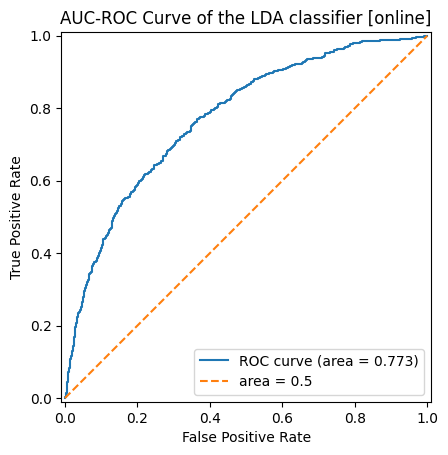

In [21]:
# This block is of the course material (unchanged, except from test_size = 0.1, which is changed to test_size = 0.2)

raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = calibration_trials

# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.2, shuffle=False) 

lda = LDA()
clf = lda.fit(X_train, y_train)

### This code is given and can be used in the subsequent exercises to build upon. unchanged

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances = np.zeros(online_words.shape)

for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            signed_distances[t,i,s] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()

In [22]:
### [OPTIONAL]: Just for fun, you can use this function that plots the distributions of the signed distances of your candidate
###   target class vs the candidate non-target classes.
def plot_distribution_comparison(target_distances, non_target_distances): 
    signed_distances = [target_distances, non_target_distances]
    labels = ['predicted target', 'predicted non-targets']
    
    all_distances = np.concatenate((target_distances,non_target_distances),axis=None)
    x_min = np.min(all_distances)
    x_man = np.max(all_distances)
    x_axis = np.linspace(x_min, x_man)

    for i, distances in enumerate(signed_distances):
        # Fit and plot the distribution of the probabilities for the non-target words.
        mean, var  = sp.stats.distributions.norm.fit(distances)
        distri = stats.norm.pdf(x_axis,mean,np.sqrt(var))
        plt.plot(x_axis, distri, label=labels[i])

    plt.legend()
    plt.title("Distributions of the distances to the hyperplane")
    plt.xlabel("predicted distance")
    plt.ylabel("probability density function")
    plt.show()    

In [23]:
# Added (to be removed)
print(online_trial_targets)
print("\nonline_labels.shape: \n",online_labels.shape)
print("\n online_labels[0]: \n",online_labels[0])
print("\n online_words.shape: \n",online_words.shape)
print("\n online_words[0]: \n",online_words[0])

print(trials[0][0]["Target"].events[:,2][0]%10) # trial 1, iter 1, target word

[2 6 4 1 5 3 4 5 3 6 2 1 4 6 3 5 1 2 4 3 6 5 2 1]

online_labels.shape: 
 (24, 15, 6)

 online_labels[0]: 
 [[0 0 0 1 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 1 0 0 0]
 [0 1 0 0 0 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 1 0 0 0]
 [0 0 1 0 0 0]]

 online_words.shape: 
 (24, 15, 6)

 online_words[0]: 
 [[6 3 4 2 5 1]
 [4 6 5 3 1 2]
 [4 6 3 5 1 2]
 [4 3 5 1 2 6]
 [3 2 4 1 5 6]
 [3 2 4 6 1 5]
 [4 3 6 1 5 2]
 [1 3 5 6 4 2]
 [6 5 2 1 3 4]
 [5 2 3 1 4 6]
 [2 3 6 1 5 4]
 [3 5 6 1 4 2]
 [3 6 4 1 5 2]
 [6 5 2 3 4 1]
 [3 5 2 4 6 1]]
2


### LDA vs sLDA vs BT-LDA

In [24]:
# added 21/04/2025: copied from above + modifications
# modifications:
# - changed clf to ldaclf which is trained on channel prime data (do not apply clf on new, channel prime data as this has not been trained on this structure. i.e., be consistent with the data structure in both fitting and testing/applying)
# - added some comments 
# - changed input to decision_function to be channel-prime through .transpose(0,2,1)
# - added slda and btlda


# added from a nr of blocks above -----------------------------------------------------
    # Run 19/04/2025_Exp_1

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Evaluation of ex. 3 

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
ldaclf = make_pipeline(LDA(),)
ldaclf.fit(X,y)
fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

### Shrinkage LDA

# slda = LDA(solver='lsqr',shrinkage = 'auto')
# slda.fit(X_train, y_train)
slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
slda.fit(X,y)

### BT-LDA

# btlda = ToeplitzLDA(n_channels= 63) 
# btlda.fit(X_train, y_train) 
nch = (trials[0][0]).info["nchan"]
btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
btlda.fit(X,y)

# -------------------------------------------------------------------------------


# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_lda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_slda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_btlda = np.zeros(online_words.shape) # (24, 15, 6)
# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

p = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
                        
            # changed to channel prime for bt-lda
            signed_distances_lda[t,i,s] = ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
            signed_distances_slda[t,i,s] = slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0]
            
            # Important note during debugging
            # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)
            signed_distances_btlda[t,i,s] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item() 


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_slda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
plt.show()



NameError: name 'X' is not defined

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


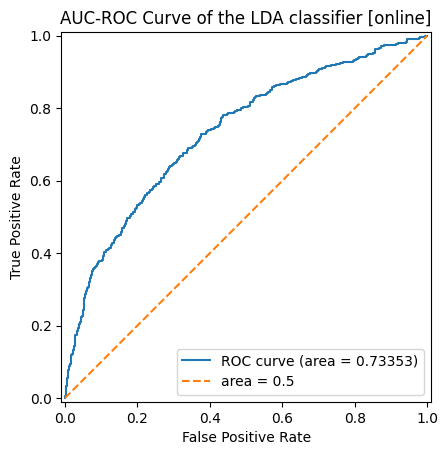

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


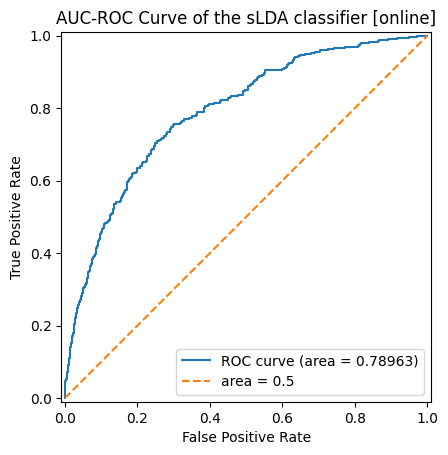

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


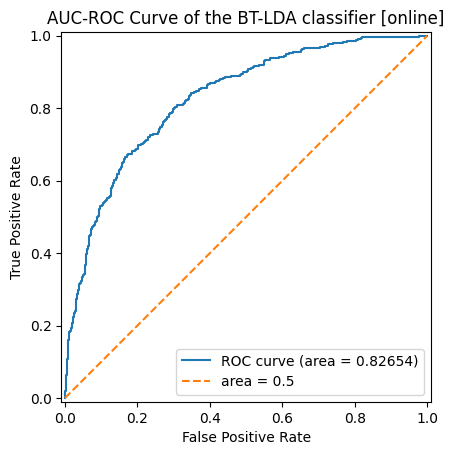

In [25]:
# added 21/04/2025: copied from above + modifications
# modifications:
# - changed clf to ldaclf which is trained on channel prime data (do not apply clf on new, channel prime data as this has not been trained on this structure. i.e., be consistent with the data structure in both fitting and testing/applying)
# - added some comments 
# - changed input to decision_function to be channel-prime through .transpose(0,2,1)
# - added slda and btlda


# added from a nr of blocks above -----------------------------------------------------
    # Run 19/04/2025_Exp_1

# clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
clf_ival_boundaries = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 

calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])

# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X = calibration_stimuli
y = calibration_labels


# Evaluation of ex. 3 

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
ldaclf = make_pipeline(LDA(),)
ldaclf.fit(X,y)

### Shrinkage LDA

# slda = LDA(solver='lsqr',shrinkage = 'auto')
# slda.fit(X_train, y_train)
slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
slda.fit(X,y)

### BT-LDA

# btlda = ToeplitzLDA(n_channels= 63) 
# btlda.fit(X_train, y_train) 
nch = (trials[0][0]).info["nchan"]
btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
btlda.fit(X,y)

# -------------------------------------------------------------------------------


# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_lda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_slda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_btlda = np.zeros(online_words.shape) # (24, 15, 6)
# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

p = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
                        
            # changed to channel prime for bt-lda
            signed_distances_lda[t,i,s] = ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
            signed_distances_slda[t,i,s] = slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0]
            
            # Important note during debugging
            # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)
            signed_distances_btlda[t,i,s] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item() 


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_slda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
plt.show()



(972, 252)
(972,)
[0 0 0 0 1 0 0 0 1 0]
[0.1 0.2 0.3 0.4 0.5]
(24, 15, 6, 63, 121)
1/2160.0
2/2160.0
3/2160.0
4/2160.0
5/2160.0
6/2160.0
7/2160.0
8/2160.0
9/2160.0
10/2160.0
11/2160.0
12/2160.0
13/2160.0
14/2160.0
15/2160.0
16/2160.0
17/2160.0
18/2160.0
19/2160.0
20/2160.0
21/2160.0
22/2160.0
23/2160.0
24/2160.0
25/2160.0
26/2160.0
27/2160.0
28/2160.0
29/2160.0
30/2160.0
31/2160.0
32/2160.0
33/2160.0
34/2160.0
35/2160.0
36/2160.0
37/2160.0
38/2160.0
39/2160.0
40/2160.0
41/2160.0
42/2160.0
43/2160.0
44/2160.0
45/2160.0
46/2160.0
47/2160.0
48/2160.0
49/2160.0
50/2160.0
51/2160.0
52/2160.0
53/2160.0
54/2160.0
55/2160.0
56/2160.0
57/2160.0
58/2160.0
59/2160.0
60/2160.0
61/2160.0
62/2160.0
63/2160.0
64/2160.0
65/2160.0
66/2160.0
67/2160.0
68/2160.0
69/2160.0
70/2160.0
71/2160.0
72/2160.0
73/2160.0
74/2160.0
75/2160.0
76/2160.0
77/2160.0
78/2160.0
79/2160.0
80/2160.0
81/2160.0
82/2160.0
83/2160.0
84/2160.0
85/2160.0
86/2160.0
87/2160.0
88/2160.0
89/2160.0
90/2160.0
91/2160.0
92/2160.0
93/216

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


2149/2160.0
2150/2160.0
2151/2160.0
2152/2160.0
2153/2160.0
2154/2160.0
2155/2160.0
2156/2160.0
2157/2160.0
2158/2160.0
2159/2160.0
2160/2160.0


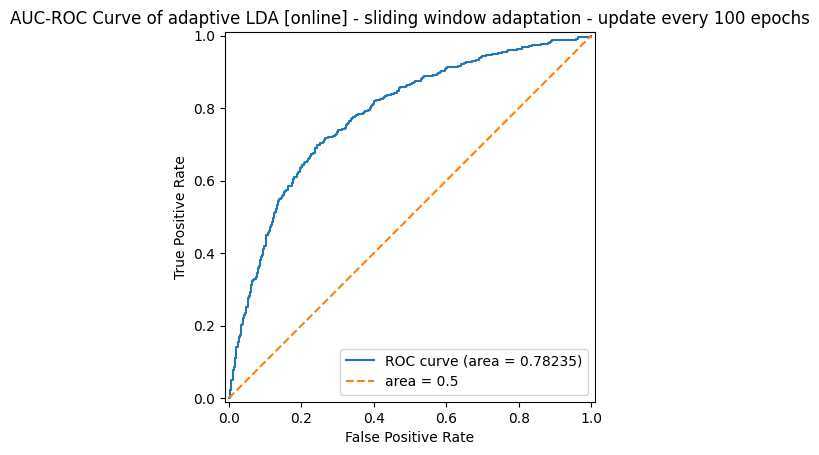

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


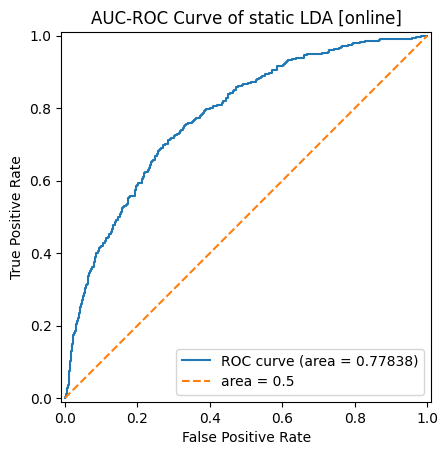

In [ ]:
# Adapting LDA from scratch first draft

# This all is from ex 3 calibration --------------------------------------------------------------------------------------------------------------
raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])
# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)
# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# --------------------------------------------------------------------------------------------------------------

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
adaptive_lda = make_pipeline(LDA(),)
adaptive_lda.fit(X_train,y_train)

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

print(X_train.shape) # (972, 252)
print(y_train.shape) # (972,)
print(y_train[0:10]) # [0 0 0 0 1 0 ...]

signed_distances_adaptive_lda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_static_lda = np.zeros(online_words.shape)

static_lda = make_pipeline(LDA(),)
static_lda.fit(X_train,y_train) # only fit once, on initial train data

# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

length = np.asarray(online_trials).flatten().shape[0] / (63*121) # total nr of epochs
print(np.asarray(online_trials).shape)

epoch_nr = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            # print(stimulus.shape) # np array (63, 121)
            new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1) # (1, 252)
            new_single_label = online_labels[t,i,s]

            signed_distances_adaptive_lda[t,i,s] = adaptive_lda.decision_function(new_single_epoch)[0] # Compute signed distance of stimulus to decision boundary
            signed_distances_static_lda[t,i,s] = static_lda.decision_function(new_single_epoch)[0]

            # update X_train and y_train data
            X_train = np.append(X_train,new_single_epoch, axis=0)
            X_train = X_train[1:]
            y_train = np.append(y_train,new_single_label)
            y_train = y_train[1:]

            # keep track of epochs
            epoch_nr += 1
            print("{}/{}".format(epoch_nr,length))

            # It takes really long so only update classifier after every 100 epochs
            step = 100
            if (epoch_nr % step == 0):
                adaptive_lda.fit(X_train, y_train)


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_adaptive_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of adaptive LDA [online] - sliding window adaptation - update every {} epochs".format(step))
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_static_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of static LDA [online]")
plt.show()


(972, 252)
(972,)
[0 0 0 0 1 0 0 0 1 0]
[0.1 0.2 0.3 0.4 0.5]
(24, 15, 6, 63, 121)
1/2160.0
2/2160.0
3/2160.0
4/2160.0
5/2160.0
6/2160.0
7/2160.0
8/2160.0
9/2160.0
10/2160.0
11/2160.0
12/2160.0
13/2160.0
14/2160.0
15/2160.0
16/2160.0
17/2160.0
18/2160.0
19/2160.0
20/2160.0
21/2160.0
22/2160.0
23/2160.0
24/2160.0
25/2160.0
26/2160.0
27/2160.0
28/2160.0
29/2160.0
30/2160.0
31/2160.0
32/2160.0
33/2160.0
34/2160.0
35/2160.0
36/2160.0
37/2160.0
38/2160.0
39/2160.0
40/2160.0
41/2160.0
42/2160.0
43/2160.0
44/2160.0
45/2160.0
46/2160.0
47/2160.0
48/2160.0
49/2160.0
50/2160.0
51/2160.0
52/2160.0
53/2160.0
54/2160.0
55/2160.0
56/2160.0
57/2160.0
58/2160.0
59/2160.0
60/2160.0
61/2160.0
62/2160.0
63/2160.0
64/2160.0
65/2160.0
66/2160.0
67/2160.0
68/2160.0
69/2160.0
70/2160.0
71/2160.0
72/2160.0
73/2160.0
74/2160.0
75/2160.0
76/2160.0
77/2160.0
78/2160.0
79/2160.0
80/2160.0
81/2160.0
82/2160.0
83/2160.0
84/2160.0
85/2160.0
86/2160.0
87/2160.0
88/2160.0
89/2160.0
90/2160.0
91/2160.0
92/2160.0
93/216

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


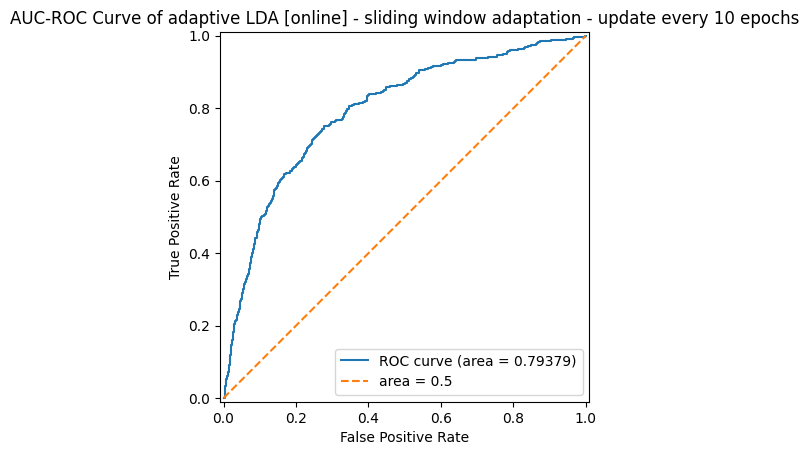

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


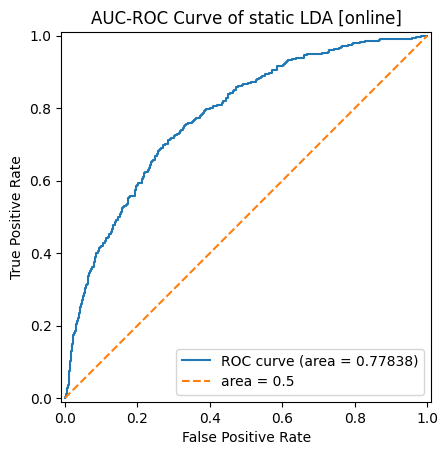

In [ ]:
# Same as above, but with step size 10 instead (runtime 1.5 mins)

# Adapting LDA from scratch first draft

# This all is from ex 3 calibration --------------------------------------------------------------------------------------------------------------
raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])
# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)
# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# --------------------------------------------------------------------------------------------------------------

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
adaptive_lda = make_pipeline(LDA(),)
adaptive_lda.fit(X_train,y_train)

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

print(X_train.shape) # (972, 252)
print(y_train.shape) # (972,)
print(y_train[0:10]) # [0 0 0 0 1 0 ...]

signed_distances_adaptive_lda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_static_lda = np.zeros(online_words.shape)

static_lda = make_pipeline(LDA(),)
static_lda.fit(X_train,y_train) # only fit once, on initial train data

# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

length = np.asarray(online_trials).flatten().shape[0] / (63*121) # total nr of epochs
print(np.asarray(online_trials).shape)

epoch_nr = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            # print(stimulus.shape) # np array (63, 121)
            new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1) # (1, 252)
            new_single_label = online_labels[t,i,s]

            signed_distances_adaptive_lda[t,i,s] = adaptive_lda.decision_function(new_single_epoch)[0] # Compute signed distance of stimulus to decision boundary
            signed_distances_static_lda[t,i,s] = static_lda.decision_function(new_single_epoch)[0]

            # update X_train and y_train data
            X_train = np.append(X_train,new_single_epoch, axis=0)
            X_train = X_train[1:]
            y_train = np.append(y_train,new_single_label)
            y_train = y_train[1:]

            # keep track of epochs
            epoch_nr += 1
            print("{}/{}".format(epoch_nr,length))

            # It takes really long so only update classifier after every 10 epochs
            step = 10
            if (epoch_nr % step == 0):
                adaptive_lda.fit(X_train, y_train)


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_adaptive_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of adaptive LDA [online] - sliding window adaptation - update every {} epochs".format(step))
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_static_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of static LDA [online]")
plt.show()


(972, 252)
(972,)
[0 0 0 0 1 0 0 0 1 0]
[0.1 0.2 0.3 0.4 0.5]
(24, 15, 6, 63, 121)
1/2160.0
2/2160.0
3/2160.0
4/2160.0
5/2160.0
6/2160.0
7/2160.0
8/2160.0
9/2160.0
10/2160.0
11/2160.0
12/2160.0
13/2160.0
14/2160.0
15/2160.0
16/2160.0
17/2160.0
18/2160.0
19/2160.0
20/2160.0
21/2160.0
22/2160.0
23/2160.0
24/2160.0
25/2160.0
26/2160.0
27/2160.0
28/2160.0
29/2160.0
30/2160.0
31/2160.0
32/2160.0
33/2160.0
34/2160.0
35/2160.0
36/2160.0
37/2160.0
38/2160.0
39/2160.0
40/2160.0
41/2160.0
42/2160.0
43/2160.0
44/2160.0
45/2160.0
46/2160.0
47/2160.0
48/2160.0
49/2160.0
50/2160.0
51/2160.0
52/2160.0
53/2160.0
54/2160.0
55/2160.0
56/2160.0
57/2160.0
58/2160.0
59/2160.0
60/2160.0
61/2160.0
62/2160.0
63/2160.0
64/2160.0
65/2160.0
66/2160.0
67/2160.0
68/2160.0
69/2160.0
70/2160.0
71/2160.0
72/2160.0
73/2160.0
74/2160.0
75/2160.0
76/2160.0
77/2160.0
78/2160.0
79/2160.0
80/2160.0
81/2160.0
82/2160.0
83/2160.0
84/2160.0
85/2160.0
86/2160.0
87/2160.0
88/2160.0
89/2160.0
90/2160.0
91/2160.0
92/2160.0
93/216

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


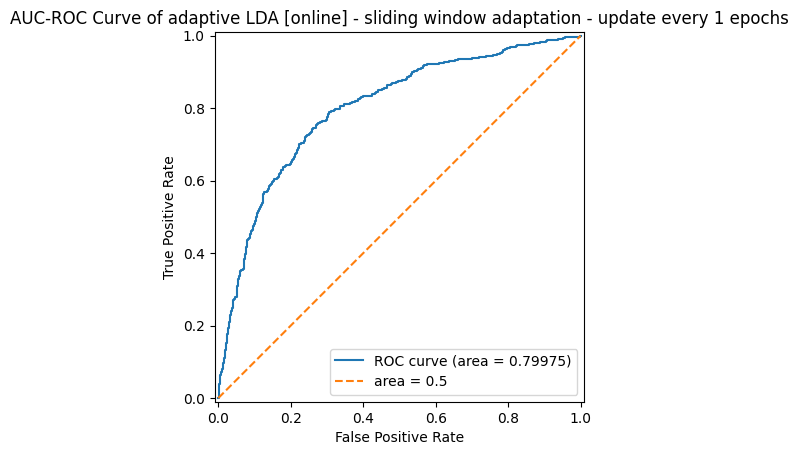

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


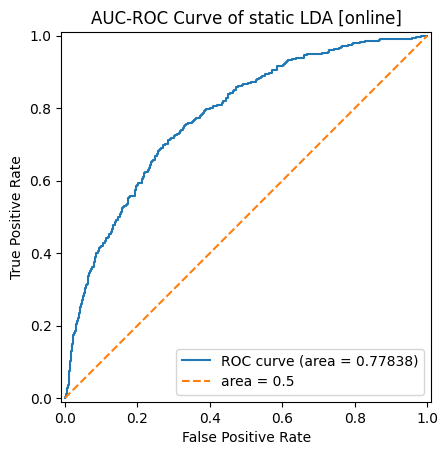

In [ ]:
# Same as above, but with step size 1 instead (runtime: 13 min)

# Adapting LDA from scratch first draft

# This all is from ex 3 calibration --------------------------------------------------------------------------------------------------------------
raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])
# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)
# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# --------------------------------------------------------------------------------------------------------------

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
adaptive_lda = make_pipeline(LDA(),)
adaptive_lda.fit(X_train,y_train)

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

print(X_train.shape) # (972, 252)
print(y_train.shape) # (972,)
print(y_train[0:10]) # [0 0 0 0 1 0 ...]

signed_distances_adaptive_lda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_static_lda = np.zeros(online_words.shape)

static_lda = make_pipeline(LDA(),)
static_lda.fit(X_train,y_train) # only fit once, on initial train data

# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

length = np.asarray(online_trials).flatten().shape[0] / (63*121) # total nr of epochs
print(np.asarray(online_trials).shape)

epoch_nr = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            # print(stimulus.shape) # np array (63, 121)
            new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1) # (1, 252)
            new_single_label = online_labels[t,i,s]

            signed_distances_adaptive_lda[t,i,s] = adaptive_lda.decision_function(new_single_epoch)[0] # Compute signed distance of stimulus to decision boundary
            signed_distances_static_lda[t,i,s] = static_lda.decision_function(new_single_epoch)[0]

            # update X_train and y_train data
            X_train = np.append(X_train,new_single_epoch, axis=0)
            X_train = X_train[1:]
            y_train = np.append(y_train,new_single_label)
            y_train = y_train[1:]

            # keep track of epochs
            epoch_nr += 1
            print("{}/{}".format(epoch_nr,length))

            # It takes really long so only update classifier after every 1 epoch # takes some time
            step = 1
            if (epoch_nr % step == 0):
                adaptive_lda.fit(X_train, y_train)


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_adaptive_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of adaptive LDA [online] - sliding window adaptation - update every {} epochs".format(step))
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_static_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of static LDA [online]")
plt.show()


[0.1 0.2 0.3 0.4 0.5]
(24, 15, 6, 63, 121)


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages

1/2160.0
2/2160.0
3/2160.0
4/2160.0
5/2160.0
6/2160.0
7/2160.0
8/2160.0
9/2160.0
10/2160.0
11/2160.0
12/2160.0
13/2160.0
14/2160.0
15/2160.0
16/2160.0
17/2160.0
18/2160.0
19/2160.0
20/2160.0
21/2160.0
22/2160.0
23/2160.0
24/2160.0
25/2160.0
26/2160.0
27/2160.0
28/2160.0
29/2160.0
30/2160.0


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages

31/2160.0
32/2160.0
33/2160.0
34/2160.0
35/2160.0
36/2160.0
37/2160.0
38/2160.0
39/2160.0
40/2160.0
41/2160.0
42/2160.0
43/2160.0
44/2160.0
45/2160.0


...

2097/2160.0
2098/2160.0
2099/2160.0
2100/2160.0


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages

2101/2160.0
2102/2160.0
2103/2160.0
2104/2160.0
2105/2160.0
2106/2160.0
2107/2160.0
2108/2160.0
2109/2160.0
2110/2160.0
2111/2160.0
2112/2160.0
2113/2160.0
2114/2160.0
2115/2160.0
2116/2160.0
2117/2160.0
2118/2160.0
2119/2160.0
2120/2160.0
2121/2160.0
2122/2160.0
2123/2160.0
2124/2160.0
2125/2160.0
2126/2160.0
2127/2160.0
2128/2160.0
2129/2160.0
2130/2160.0
2131/2160.0
2132/2160.0
2133/2160.0
2134/2160.0


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages

2135/2160.0
2136/2160.0
2137/2160.0
2138/2160.0
2139/2160.0
2140/2160.0
2141/2160.0
2142/2160.0
2143/2160.0
2144/2160.0
2145/2160.0
2146/2160.0
2147/2160.0
2148/2160.0
2149/2160.0
2150/2160.0
2151/2160.0
2152/2160.0
2153/2160.0
2154/2160.0
2155/2160.0
2156/2160.0
2157/2160.0
2158/2160.0
2159/2160.0
2160/2160.0


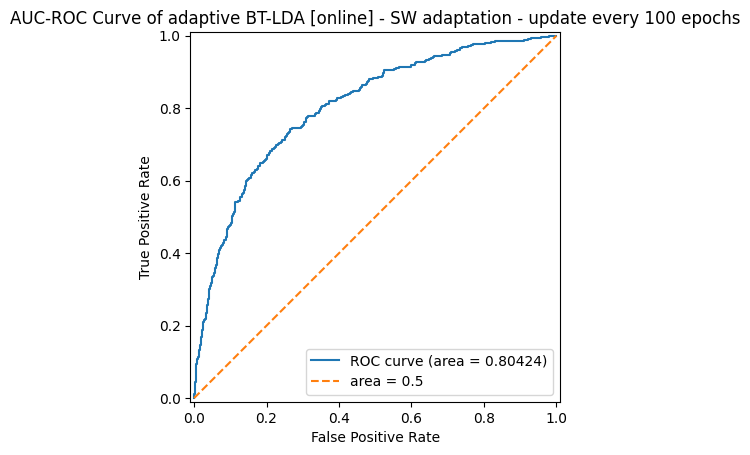

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


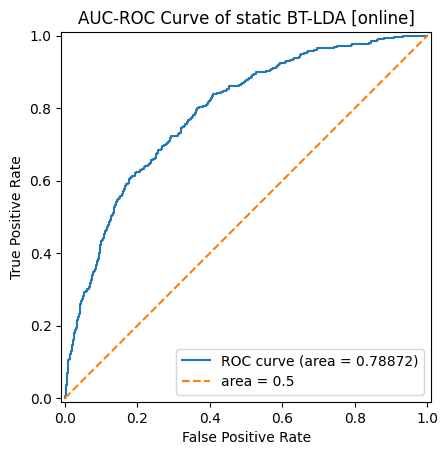

In [ ]:
# Adapting BT-LDA from scratch first draft - every 100 epochs

# This all is from ex 3 calibration --------------------------------------------------------------------------------------------------------------
raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])
# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)
# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# --------------------------------------------------------------------------------------------------------------

### LDA

# # lda = LDA()
# # ldaclf = lda.fit(X_train, y_train)
# adaptive_lda = make_pipeline(LDA(),)
# adaptive_lda.fit(X_train,y_train)

### BT-LDA
nch = (trials[0][0]).info["nchan"]
adaptive_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
adaptive_btlda.fit(X_train,y_train)

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_adaptive_btlda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_static_btlda = np.zeros(online_words.shape)

nch = (trials[0][0]).info["nchan"]
static_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
static_btlda.fit(X_train,y_train) # only fit once, on initial train data

# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

length = np.asarray(online_trials).flatten().shape[0] / (63*121) # total nr of epochs
print(np.asarray(online_trials).shape)

epoch_nr = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            # print(stimulus.shape) # np array (63, 121)
            new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1) # (1, 252)
            new_single_label = online_labels[t,i,s]

            signed_distances_adaptive_btlda[t,i,s] = adaptive_btlda.decision_function(new_single_epoch).item() 
            signed_distances_static_btlda[t,i,s] = static_btlda.decision_function(new_single_epoch).item()

            # update X_train and y_train data
            X_train = np.append(X_train,new_single_epoch, axis=0)
            X_train = X_train[1:]
            y_train = np.append(y_train,new_single_label)
            y_train = y_train[1:]

            # keep track of epochs
            epoch_nr += 1
            print("{}/{}".format(epoch_nr,length))

            # It takes some time so only update classifier after every 100 epochs
            step = 100
            if (epoch_nr % step == 0):
                adaptive_btlda.fit(X_train, y_train)


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_adaptive_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of adaptive BT-LDA [online] - SW adaptation - update every {} epochs".format(step))
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_static_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of static BT-LDA [online]")
plt.show()


[0.1 0.2 0.3 0.4 0.5]
(24, 15, 6, 63, 121)
1/2160.0
2/2160.0
3/2160.0
4/2160.0
5/2160.0
6/2160.0
7/2160.0
8/2160.0
9/2160.0
10/2160.0
11/2160.0
12/2160.0
13/2160.0
14/2160.0
15/2160.0
16/2160.0
17/2160.0
18/2160.0
19/2160.0
20/2160.0
21/2160.0
22/2160.0
23/2160.0
24/2160.0
25/2160.0
26/2160.0
27/2160.0
28/2160.0
29/2160.0
30/2160.0
31/2160.0
32/2160.0
33/2160.0
34/2160.0
35/2160.0
36/2160.0
37/2160.0
38/2160.0
39/2160.0
40/2160.0
41/2160.0
42/2160.0
43/2160.0
44/2160.0
45/2160.0
46/2160.0
47/2160.0
48/2160.0
49/2160.0
50/2160.0
51/2160.0
52/2160.0
53/2160.0
54/2160.0
55/2160.0
56/2160.0
57/2160.0
58/2160.0
59/2160.0
60/2160.0
61/2160.0
62/2160.0
63/2160.0
64/2160.0
65/2160.0
66/2160.0
67/2160.0
68/2160.0
69/2160.0
70/2160.0
71/2160.0
72/2160.0
73/2160.0
74/2160.0
75/2160.0
76/2160.0
77/2160.0
78/2160.0
79/2160.0
80/2160.0
81/2160.0
82/2160.0
83/2160.0
84/2160.0
85/2160.0
86/2160.0
87/2160.0
88/2160.0
89/2160.0
90/2160.0
91/2160.0
92/2160.0
93/2160.0
94/2160.0
95/2160.0
96/2160.0
97/216

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


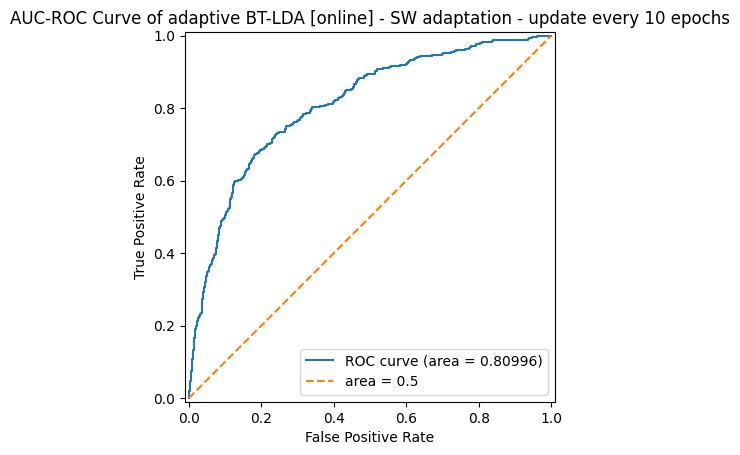

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


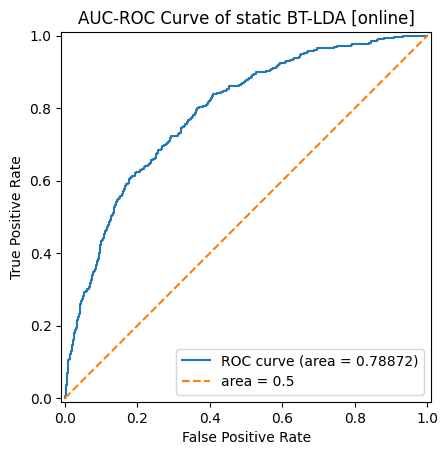

In [33]:
# Adapting BT-LDA from scratch first draft - every 10 epochs instead of 100 (runtime 25 s)

# added to get rid of the future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# This all is from ex 3 calibration --------------------------------------------------------------------------------------------------------------
raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])
# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)
# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# --------------------------------------------------------------------------------------------------------------

### LDA

# # lda = LDA()
# # ldaclf = lda.fit(X_train, y_train)
# adaptive_lda = make_pipeline(LDA(),)
# adaptive_lda.fit(X_train,y_train)

### BT-LDA
nch = (trials[0][0]).info["nchan"]
adaptive_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
adaptive_btlda.fit(X_train,y_train)

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_adaptive_btlda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_static_btlda = np.zeros(online_words.shape)

nch = (trials[0][0]).info["nchan"]
static_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
static_btlda.fit(X_train,y_train) # only fit once, on initial train data

# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

length = np.asarray(online_trials).flatten().shape[0] / (63*121) # total nr of epochs
print(np.asarray(online_trials).shape)

epoch_nr = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            # print(stimulus.shape) # np array (63, 121)
            new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1) # (1, 252)
            new_single_label = online_labels[t,i,s]

            signed_distances_adaptive_btlda[t,i,s] = adaptive_btlda.decision_function(new_single_epoch).item() 
            signed_distances_static_btlda[t,i,s] = static_btlda.decision_function(new_single_epoch).item()

            # update X_train and y_train data
            X_train = np.append(X_train,new_single_epoch, axis=0)
            X_train = X_train[1:]
            y_train = np.append(y_train,new_single_label)
            y_train = y_train[1:]

            # keep track of epochs
            epoch_nr += 1
            print("{}/{}".format(epoch_nr,length))

            # It takes some time so only update classifier after every 10 epochs
            step = 10
            if (epoch_nr % step == 0):
                adaptive_btlda.fit(X_train, y_train)


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_adaptive_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of adaptive BT-LDA [online] - SW adaptation - update every {} epochs".format(step))
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_static_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of static BT-LDA [online]")
plt.show()


In [ ]:
# Comparing AUC scores from 4-fold cv vs from a single train_test_split
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=True)

# Using single train_test_split
print("\nUsing single train test split:")
compare_auc_single_trial_interval(trials,test_size=0.2, ival_bounds = clf_ival_boundaries, plot_roc_curves=False)

Using 4-fold cross-validation:
Mean AUC score of LDA:  0.7716296296296297
Mean AUC score of sLDA:  0.7519506172839506
Mean AUC score of BT-LDA:  0.754320987654321

Using single train test split:
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.817746913580247
AUC SLDA:  0.8265432098765431
AUC BT-LDA:  0.8294753086419753


[0.1 0.2 0.3 0.4 0.5]
(24, 15, 6, 63, 121)
1/2160.0
2/2160.0
3/2160.0
4/2160.0
5/2160.0
6/2160.0
7/2160.0
8/2160.0
9/2160.0
10/2160.0
11/2160.0
12/2160.0
13/2160.0
14/2160.0
15/2160.0
16/2160.0
17/2160.0
18/2160.0
19/2160.0
20/2160.0
21/2160.0
22/2160.0
23/2160.0
24/2160.0
25/2160.0
26/2160.0
27/2160.0
28/2160.0
29/2160.0
30/2160.0
31/2160.0
32/2160.0
33/2160.0
34/2160.0
35/2160.0
36/2160.0
37/2160.0
38/2160.0
39/2160.0
40/2160.0
41/2160.0
42/2160.0
43/2160.0
44/2160.0
45/2160.0
46/2160.0
47/2160.0
48/2160.0
49/2160.0
50/2160.0
51/2160.0
52/2160.0
53/2160.0
54/2160.0
55/2160.0
56/2160.0
57/2160.0
58/2160.0
59/2160.0
60/2160.0
61/2160.0
62/2160.0
63/2160.0
64/2160.0
65/2160.0
66/2160.0
67/2160.0
68/2160.0
69/2160.0
70/2160.0
71/2160.0
72/2160.0
73/2160.0
74/2160.0
75/2160.0
76/2160.0
77/2160.0
78/2160.0
79/2160.0
80/2160.0
81/2160.0
82/2160.0
83/2160.0
84/2160.0
85/2160.0
86/2160.0
87/2160.0
88/2160.0
89/2160.0
90/2160.0
91/2160.0
92/2160.0
93/2160.0
94/2160.0
95/2160.0
96/2160.0
97/216

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


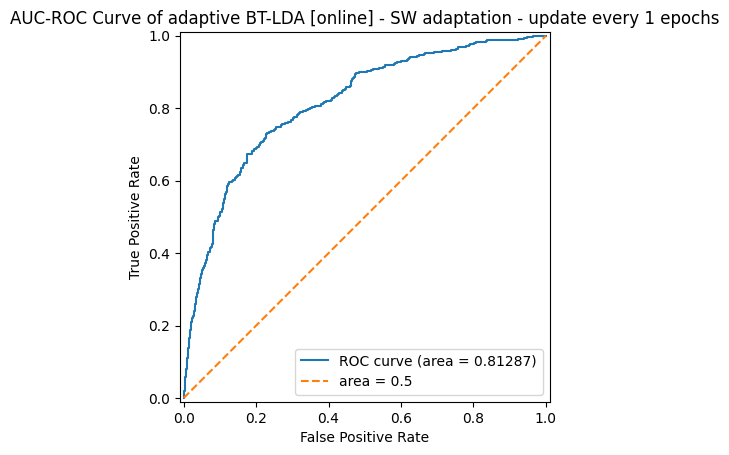

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


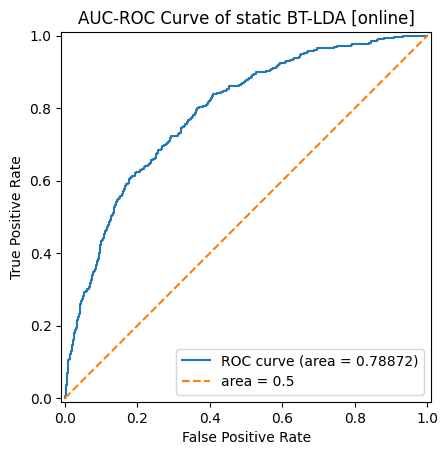

In [34]:
# Adapting BT-LDA from scratch first draft - every epoch instead of 100 or 10 (runtime )

# added to get rid of the future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# This all is from ex 3 calibration --------------------------------------------------------------------------------------------------------------
raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])
# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)
# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# --------------------------------------------------------------------------------------------------------------

### LDA

# # lda = LDA()
# # ldaclf = lda.fit(X_train, y_train)
# adaptive_lda = make_pipeline(LDA(),)
# adaptive_lda.fit(X_train,y_train)

### BT-LDA
nch = (trials[0][0]).info["nchan"]
adaptive_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
adaptive_btlda.fit(X_train,y_train)

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_adaptive_btlda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_static_btlda = np.zeros(online_words.shape)

nch = (trials[0][0]).info["nchan"]
static_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
static_btlda.fit(X_train,y_train) # only fit once, on initial train data

# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

length = np.asarray(online_trials).flatten().shape[0] / (63*121) # total nr of epochs
print(np.asarray(online_trials).shape)

epoch_nr = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            # print(stimulus.shape) # np array (63, 121)
            new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1) # (1, 252)
            new_single_label = online_labels[t,i,s]

            signed_distances_adaptive_btlda[t,i,s] = adaptive_btlda.decision_function(new_single_epoch).item() 
            signed_distances_static_btlda[t,i,s] = static_btlda.decision_function(new_single_epoch).item()

            # update X_train and y_train data
            X_train = np.append(X_train,new_single_epoch, axis=0)
            X_train = X_train[1:]
            y_train = np.append(y_train,new_single_label)
            y_train = y_train[1:]

            # keep track of epochs
            epoch_nr += 1
            print("{}/{}".format(epoch_nr,length))

            # It takes some time so only update classifier after every 1 epoch
            step = 1
            if (epoch_nr % step == 0):
                adaptive_btlda.fit(X_train, y_train)


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_adaptive_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of adaptive BT-LDA [online] - SW adaptation - update every {} epochs".format(step))
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_static_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of static BT-LDA [online]")
plt.show()


In [112]:
# Comparing AUC scores from 4-fold cv vs from a single train_test_split
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=True)

# Using single train_test_split
print("\nUsing single train test split:")
compare_auc_single_trial_interval(trials,test_size=0.2, ival_bounds = clf_ival_boundaries, plot_roc_curves=False)

Using 4-fold cross-validation:


TypeError: compute_auc_with_cv() got an unexpected keyword argument 'show_only_mean'

[0.1 0.2 0.3 0.4 0.5]
(24, 15, 6, 63, 121)
1/2160.0
2/2160.0
3/2160.0
4/2160.0
5/2160.0
6/2160.0
7/2160.0
8/2160.0
9/2160.0
10/2160.0
11/2160.0
12/2160.0
13/2160.0
14/2160.0
15/2160.0
16/2160.0
17/2160.0
18/2160.0
19/2160.0
20/2160.0
21/2160.0
22/2160.0
23/2160.0
24/2160.0
25/2160.0
26/2160.0
27/2160.0
28/2160.0
29/2160.0
30/2160.0
31/2160.0
32/2160.0
33/2160.0
34/2160.0
35/2160.0
36/2160.0
37/2160.0
38/2160.0
39/2160.0
40/2160.0
41/2160.0
42/2160.0
43/2160.0
44/2160.0
45/2160.0
46/2160.0
47/2160.0
48/2160.0
49/2160.0
50/2160.0
51/2160.0
52/2160.0
53/2160.0
54/2160.0
55/2160.0
56/2160.0
57/2160.0
58/2160.0
59/2160.0
60/2160.0
61/2160.0
62/2160.0
63/2160.0
64/2160.0
65/2160.0
66/2160.0
67/2160.0
68/2160.0
69/2160.0
70/2160.0
71/2160.0
72/2160.0
73/2160.0
74/2160.0
75/2160.0
76/2160.0
77/2160.0
78/2160.0
79/2160.0
80/2160.0
81/2160.0
82/2160.0
83/2160.0
84/2160.0
85/2160.0
86/2160.0
87/2160.0
88/2160.0
89/2160.0
90/2160.0
91/2160.0
92/2160.0
93/2160.0
94/2160.0
95/2160.0
96/2160.0
97/216

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


2141/2160.0
2142/2160.0
2143/2160.0
2144/2160.0
2145/2160.0
2146/2160.0
2147/2160.0
2148/2160.0
2149/2160.0
2150/2160.0
2151/2160.0
2152/2160.0
2153/2160.0
2154/2160.0
2155/2160.0
2156/2160.0
2157/2160.0
2158/2160.0
2159/2160.0
2160/2160.0


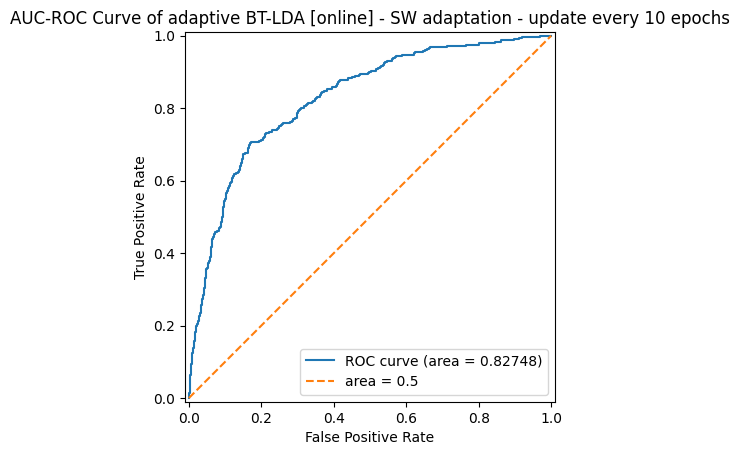

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


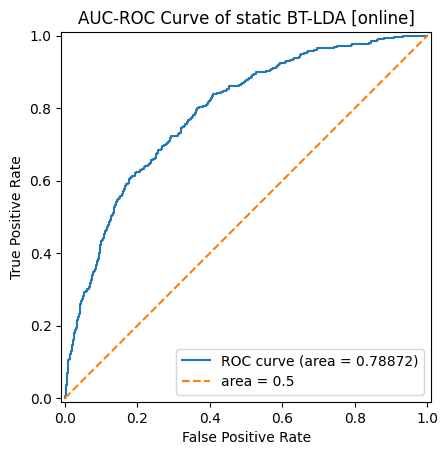

In [ ]:
# Adapting BT-LDA from scratch first draft - every 10 epochs - change: accept window size of max 24 trials (instead of 12)
# note that the comparison with static lda in this block is not really fair... static lda was trained on 12 trials

# added to get rid of the future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# This all is from ex 3 calibration --------------------------------------------------------------------------------------------------------------
raw_calibration_trials = trials[0:12] # change start & stop trial
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])
# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)
# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# --------------------------------------------------------------------------------------------------------------

### LDA

# # lda = LDA()
# # ldaclf = lda.fit(X_train, y_train)
# adaptive_lda = make_pipeline(LDA(),)
# adaptive_lda.fit(X_train,y_train)

### BT-LDA
nch = (trials[0][0]).info["nchan"]
adaptive_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
adaptive_btlda.fit(X_train,y_train)

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_adaptive_btlda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_static_btlda = np.zeros(online_words.shape)

nch = (trials[0][0]).info["nchan"]
static_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
static_btlda.fit(X_train,y_train) # only fit once, on initial train data

# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

length = np.asarray(online_trials).flatten().shape[0] / (63*121) # total nr of epochs
print(np.asarray(online_trials).shape)

epoch_nr = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            # print(stimulus.shape) # np array (63, 121)
            new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1) # (1, 252)
            new_single_label = online_labels[t,i,s]

            signed_distances_adaptive_btlda[t,i,s] = adaptive_btlda.decision_function(new_single_epoch).item() 
            signed_distances_static_btlda[t,i,s] = static_btlda.decision_function(new_single_epoch).item()

            # update X_train and y_train data
            X_train = np.append(X_train,new_single_epoch, axis=0)
            y_train = np.append(y_train,new_single_label)

            # remove old data only when we have reached over 24 trials in our dataset 
            if t>12:
                X_train = X_train[1:]
                y_train = y_train[1:]

            # keep track of epochs
            epoch_nr += 1
            print("{}/{}".format(epoch_nr,length))

            # It takes some time so only update classifier after every 10 epochs
            step = 10
            if (epoch_nr % step == 0):
                adaptive_btlda.fit(X_train, y_train)


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_adaptive_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of adaptive BT-LDA [online] - SW adaptation - update every {} epochs".format(step))
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_static_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of static BT-LDA [online]")
plt.show()


[0.1 0.2 0.3 0.4 0.5]
(12, 15, 6, 63, 121)
1/1080.0
2/1080.0
3/1080.0
4/1080.0
5/1080.0
6/1080.0
7/1080.0
8/1080.0
9/1080.0
10/1080.0
11/1080.0
12/1080.0
13/1080.0
14/1080.0
15/1080.0
16/1080.0
17/1080.0
18/1080.0
19/1080.0
20/1080.0
21/1080.0
22/1080.0
23/1080.0
24/1080.0
25/1080.0
26/1080.0
27/1080.0
28/1080.0
29/1080.0
30/1080.0
31/1080.0
32/1080.0
33/1080.0
34/1080.0
35/1080.0
36/1080.0
37/1080.0
38/1080.0
39/1080.0
40/1080.0
41/1080.0
42/1080.0
43/1080.0
44/1080.0
45/1080.0
46/1080.0
47/1080.0
48/1080.0
49/1080.0
50/1080.0
51/1080.0
52/1080.0
53/1080.0
54/1080.0
55/1080.0
56/1080.0
57/1080.0
58/1080.0
59/1080.0
60/1080.0
61/1080.0
62/1080.0
63/1080.0
64/1080.0
65/1080.0
66/1080.0
67/1080.0
68/1080.0
69/1080.0
70/1080.0
71/1080.0
72/1080.0
73/1080.0
74/1080.0
75/1080.0
76/1080.0
77/1080.0
78/1080.0
79/1080.0
80/1080.0
81/1080.0
82/1080.0
83/1080.0
84/1080.0
85/1080.0
86/1080.0
87/1080.0
88/1080.0
89/1080.0
90/1080.0
91/1080.0
92/1080.0
93/1080.0
94/1080.0
95/1080.0
96/1080.0
97/108

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1078/1080.0
1079/1080.0
1080/1080.0


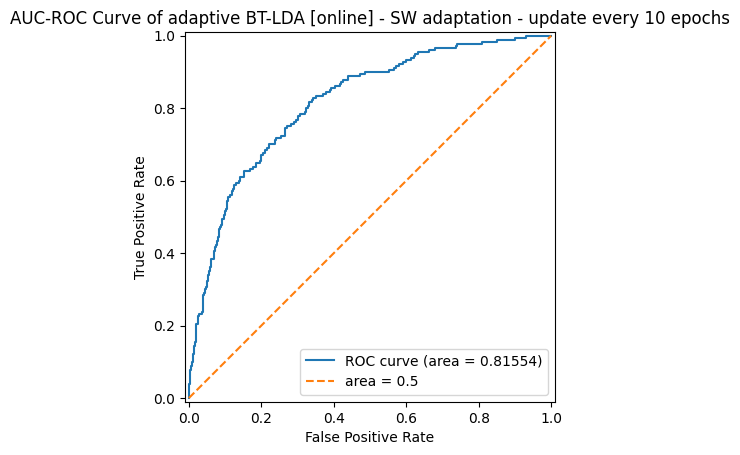

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


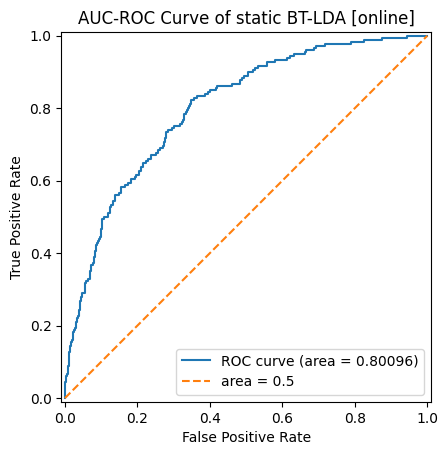

In [ ]:
# Adapting BT-LDA from scratch first draft - every 10 epochs - change: accept window size of max 24 trials (instead of 12)

# added to get rid of the future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# This all is from ex 3 calibration --------------------------------------------------------------------------------------------------------------
raw_calibration_trials = trials[0:24] # change start & stop trial
online_trials = trials[24:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])
# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)
# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# --------------------------------------------------------------------------------------------------------------

### LDA

# # lda = LDA()
# # ldaclf = lda.fit(X_train, y_train)
# adaptive_lda = make_pipeline(LDA(),)
# adaptive_lda.fit(X_train,y_train)

### BT-LDA
nch = (trials[0][0]).info["nchan"]
adaptive_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
adaptive_btlda.fit(X_train,y_train)

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_adaptive_btlda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_static_btlda = np.zeros(online_words.shape)

nch = (trials[0][0]).info["nchan"]
static_btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
static_btlda.fit(X_train,y_train) # only fit once, on initial train data

# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

length = np.asarray(online_trials).flatten().shape[0] / (63*121) # total nr of epochs
print(np.asarray(online_trials).shape)

epoch_nr = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            # print(stimulus.shape) # np array (63, 121)
            new_single_epoch = get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1) # (1, 252)
            new_single_label = online_labels[t,i,s]

            signed_distances_adaptive_btlda[t,i,s] = adaptive_btlda.decision_function(new_single_epoch).item() 
            signed_distances_static_btlda[t,i,s] = static_btlda.decision_function(new_single_epoch).item()

            # update X_train and y_train data
            X_train = np.append(X_train,new_single_epoch, axis=0)
            y_train = np.append(y_train,new_single_label)

            # remove old data only when we have reached over 24 trials in our dataset 
            if t>12:
                X_train = X_train[1:]
                y_train = y_train[1:]

            # keep track of epochs
            epoch_nr += 1
            print("{}/{}".format(epoch_nr,length))

            # It takes some time so only update classifier after every 10 epochs
            step = 10
            if (epoch_nr % step == 0):
                adaptive_btlda.fit(X_train, y_train)


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_adaptive_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of adaptive BT-LDA [online] - SW adaptation - update every {} epochs".format(step))
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_static_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of static BT-LDA [online]")
plt.show()


In [ ]:
### Answer here for 4.2 (Condition A, no dynamic stopping applied)

In [ ]:
### Answer here for 4.3 & 4.4 (Condition B, dynamic stopping applied + reporting the average accuracy and trial duration)

In [ ]:
### Example progress bar code, super useful and easy to use!
# You might have to run this once if you don't yet have the package:
#!pip install tqdm

import time
from tqdm.notebook import tqdm

array = np.arange(1,100,1)
for i, item in enumerate(tqdm(array)):
    time.sleep(0.02)

  0%|          | 0/99 [00:00<?, ?it/s]

In [ ]:
### Answer here for 4.5 (Visualisation of the trade-offs)

Trial 0 target prediction: word 5 with p-value of 0.007131
Trial 1 target prediction: word 6 with p-value of 0.001043
Trial 2 target prediction: word 3 with p-value of 0.000001
Trial 3 target prediction: word 5 with p-value of 0.046507
Trial 4 target prediction: word 1 with p-value of 0.000069
Trial 5 target prediction: word 2 with p-value of 0.018851
Trial 6 target prediction: word 4 with p-value of 0.000978
Trial 7 target prediction: word 3 with p-value of 0.139230
Trial 8 target prediction: word 6 with p-value of 0.000539
Trial 9 target prediction: word 5 with p-value of 0.006205
Trial 10 target prediction: word 2 with p-value of 0.007758
Trial 11 target prediction: word 1 with p-value of 0.000001


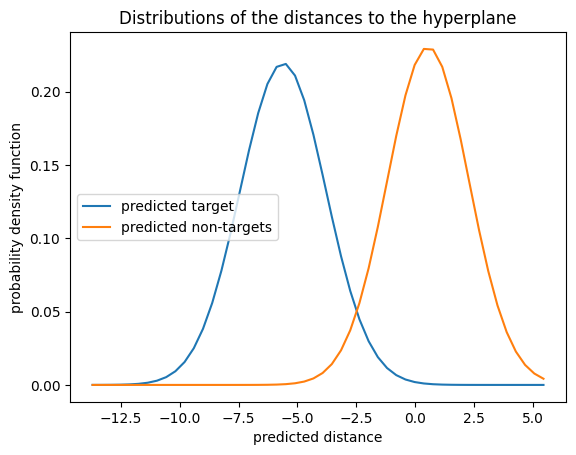

Accuracy: 0.91667


In [ ]:
# Solution 4.2
trial_predictions = np.zeros(online_trial_targets.shape)
for t, trial in enumerate(online_trials):
    stim_distances = np.zeros(online_labels.shape[1:3])
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            played_word = online_words[t,i,s] - 1 # to convert to indices
            stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
    means = np.mean(stim_distances, axis=0) # get the mean distance for each word
    best_guess = np.argmax(means)
    best_distances = stim_distances[:, best_guess].flatten()
    not_best_distances = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
    t_score, p = stats.ttest_ind(best_distances, not_best_distances, equal_var = False)
    trial_predictions[t] = best_guess + 1
    print("Trial %d target prediction: word %d with p-value of %0.6f" % (t, best_guess+1, p))    

plot_distribution_comparison(not_best_distances, best_distances)
print("Accuracy: %0.5f" % np.mean(trial_predictions == online_trial_targets))

Trial 0 target prediction: word 4 with p-value of 0.000098
Trial 1 target prediction: word 6 with p-value of 0.000004
Trial 2 target prediction: word 3 with p-value of 0.000000
Trial 3 target prediction: word 5 with p-value of 0.001800
Trial 4 target prediction: word 1 with p-value of 0.000054
Trial 5 target prediction: word 2 with p-value of 0.000130
Trial 6 target prediction: word 4 with p-value of 0.000085
Trial 7 target prediction: word 3 with p-value of 0.000009
Trial 8 target prediction: word 6 with p-value of 0.000003
Trial 9 target prediction: word 5 with p-value of 0.000247
Trial 10 target prediction: word 2 with p-value of 0.000207
Trial 11 target prediction: word 1 with p-value of 0.000000


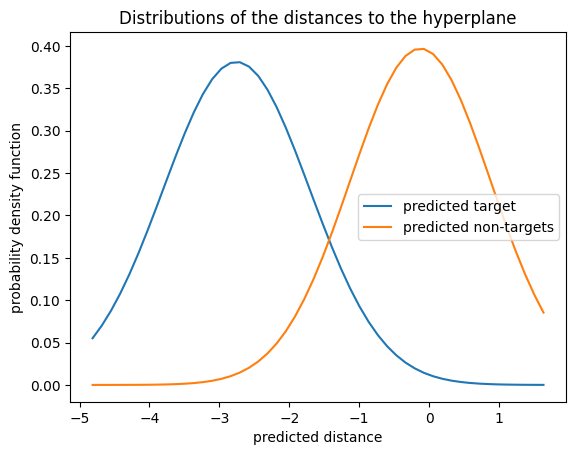

Accuracy: 1.00000


In [ ]:
# copiedd from above 
# added BT-LDA

nch = (trials[0][0]).info["nchan"]
btlda = make_pipeline(
    ToeplitzLDA(n_channels=nch),
)
btlda.fit(X_train,y_train)

trial_predictions = np.zeros(online_trial_targets.shape)
for t, trial in enumerate(online_trials):
    stim_distances = np.zeros(online_labels.shape[1:3])
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            played_word = online_words[t,i,s] - 1 # to convert to indices
            stim_distances[i,played_word] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item() # Compute signed distance of stimulus to decision boundary
            
    means = np.mean(stim_distances, axis=0) # get the mean distance for each word
    best_guess = np.argmax(means)
    best_distances = stim_distances[:, best_guess].flatten()
    not_best_distances = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
    t_score, p = stats.ttest_ind(best_distances, not_best_distances, equal_var = False)
    trial_predictions[t] = best_guess + 1
    print("Trial %d target prediction: word %d with p-value of %0.6f" % (t, best_guess+1, p))    

plot_distribution_comparison(not_best_distances, best_distances)
print("Accuracy: %0.5f" % np.mean(trial_predictions == online_trial_targets))

In [ ]:
# Solution 4.3 & 4.4

trial_predictions = np.zeros(online_trial_targets.shape)
trial_times = np.zeros(online_trial_targets.shape)

p_threshold = 0.1

for t, trial in enumerate(online_trials):
    stim_distances = np.zeros(online_labels.shape[1:3])
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            played_word = online_words[t,i,s] - 1 # to convert to indices
            stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
        if (i>5): # after 5/15 iteration
            means = np.mean(stim_distances, axis=0) # get the mean distance for each word
            best_guess = np.argmax(means)
            best_dist = stim_distances[:, best_guess].flatten()
            not_best_dist = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
            t_score, p_val = stats.ttest_ind(best_dist, not_best_dist, equal_var = False) # equal_var = False gives us welch's t-test
            
            # Dynamic stopping
            if p_val<p_threshold or i==len(trial)-1:
                trial_times[t] = i
                trial_predictions[t] = best_guess + 1
                print("Trial %d was predicted with class %d after %d iterations with p-value of %0.6f" % (t, best_guess+1, i, p)) 
                break


_,_,n_stimuli,_, n_samples = np.array(online_trials).shape

# convert to seconds
print("Each iteration takes: %0.2f seconds to complete" % (n_stimuli*n_samples/epochs.info["sfreq"]))
trial_time_seconds = trial_times*(n_stimuli*n_samples/epochs.info["sfreq"]) 

print("The experiment took %0.2f seconds to complete" % np.sum(trial_time_seconds))
print("Each trial taking %0.2f seconds on average" % np.mean(trial_time_seconds))
print("The experiment achieved %0.2f %% accuracy" % (np.mean(trial_predictions == online_trial_targets)*100))


Trial 0 was predicted with class 2 after 6 iterations with p-value of 0.000001
Trial 1 was predicted with class 6 after 6 iterations with p-value of 0.000001
Trial 2 was predicted with class 4 after 6 iterations with p-value of 0.000001
Trial 3 was predicted with class 1 after 9 iterations with p-value of 0.000001
Trial 4 was predicted with class 5 after 6 iterations with p-value of 0.000001
Trial 5 was predicted with class 3 after 6 iterations with p-value of 0.000001
Trial 6 was predicted with class 4 after 6 iterations with p-value of 0.000001
Trial 7 was predicted with class 5 after 6 iterations with p-value of 0.000001
Trial 8 was predicted with class 3 after 6 iterations with p-value of 0.000001
Trial 9 was predicted with class 6 after 6 iterations with p-value of 0.000001
Trial 10 was predicted with class 2 after 6 iterations with p-value of 0.000001
Trial 11 was predicted with class 1 after 6 iterations with p-value of 0.000001
Trial 12 was predicted with class 5 after 8 iterat

In [ ]:
print(best_dist)
print(not_best_dist)

[-0.0614656  -2.58344812  0.10335954 -3.52346143  2.91485361 -9.03651175
  1.47490863  0.          0.          0.          0.          0.
  0.          0.          0.        ]
[ -3.74200694  -4.15245081  -4.71362542  -5.10232963  -2.57360692
  -8.83247766  -3.18231051  -9.63821338  -5.81336401   4.97147001
  -4.40846216  -5.21778471  -6.26923514  -5.89335557  -7.12675296
  -4.18804977  -5.17905841  -7.00607164  -7.84797104  -4.46278271
  -7.41385914  -3.16105154  -4.47897914  -9.63030666  -9.77689614
  -2.49623678 -11.91201474  -7.43603397  -3.61510024  -3.37624585
  -2.67936687 -11.92912714  -4.83109723  -0.53223581  -5.10945776
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.         

In [ ]:
# Solution 4.5

from tqdm.notebook import tqdm

n_trials,n_iterations,n_stimuli,_, n_samples = np.array(online_trials).shape
p_thresholds = np.arange(start=0.01,stop=0.5,step=0.01)
n_p_thresholds = p_thresholds.shape[0]

p_accuracy = np.zeros((n_p_thresholds))
p_trial_times = np.zeros((n_p_thresholds, n_trials))

for p, p_threshold in enumerate(p_thresholds):
    trial_predictions = np.zeros(n_trials)
    for t, trial in enumerate(online_trials):
        stim_distances = np.zeros(online_labels.shape[1:3])
        for i, iteration in enumerate(trial):
            for s, stimulus in enumerate(iteration):
                played_word = online_words[t,i,s] - 1 # to convert to indices
                stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            if (i>4):
                means = np.mean(stim_distances, axis=0) # get the mean distance for each word
                best_guess = np.argmax(means)
                best_dist = stim_distances[:, best_guess].flatten()
                not_best_dist = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
                t_score, p_val = stats.ttest_ind(best_dist, not_best_dist, equal_var = False)
                # Dynamic stopping
                if p_val<p_threshold or i==len(trial)-1:
                    p_trial_times[p][t] = i
                    trial_predictions[t] = best_guess + 1
                    break
    p_accuracy[p] = np.mean(trial_predictions == online_trial_targets)*100


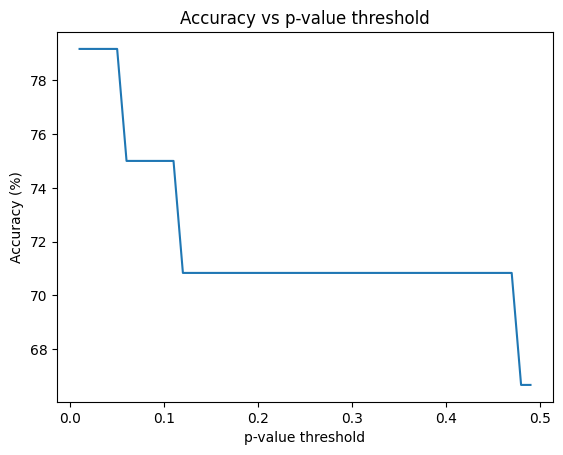

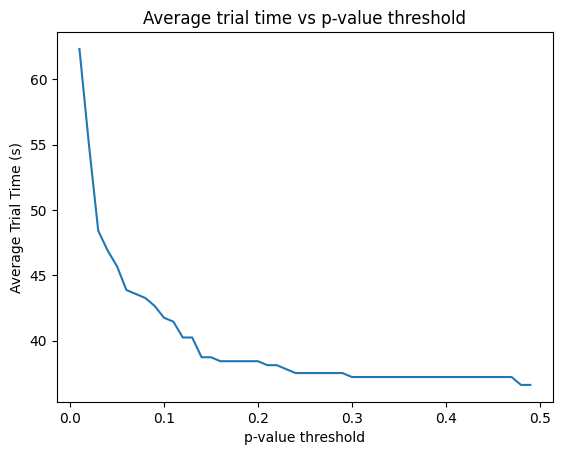

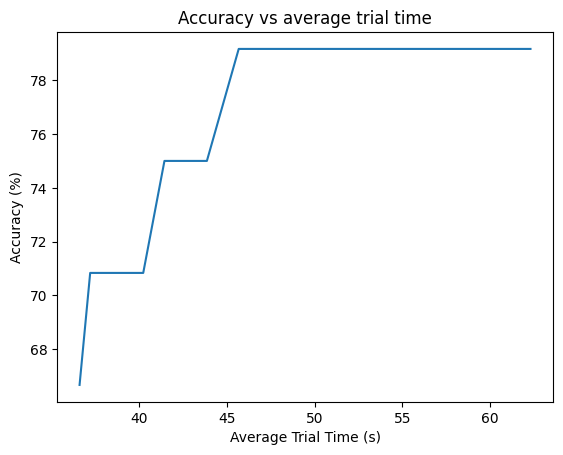

In [ ]:
# 4.5 continued
# convert trial times from iterations to seconds
trial_time_seconds = p_trial_times*(n_stimuli*n_samples/epochs.info["sfreq"]) 

plt.plot(p_thresholds, p_accuracy)
plt.title("Accuracy vs p-value threshold")
plt.xlabel('p-value threshold')
plt.ylabel('Accuracy (%)')
plt.show()

plt.plot(p_thresholds, np.mean(trial_time_seconds,axis=1))
plt.title("Average trial time vs p-value threshold")
plt.ylabel('Average Trial Time (s)')
plt.xlabel('p-value threshold')
plt.show()

plt.plot(np.mean(trial_time_seconds, axis = 1), p_accuracy)
plt.title("Accuracy vs average trial time")
plt.xlabel('Average Trial Time (s)')
plt.ylabel('Accuracy (%)')
plt.show()
